This notebook requires the base anaconda environment because I was not able to install statsmodels in the colony_patterns environment

In [35]:
import os
import glob
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import pandas as pd
import seaborn as sns
import sys
from statsmodels.formula.api import mixedlm
import statsmodels.formula.api as smf
from scipy.stats import ttest_rel, ttest_1samp, wilcoxon, chi2

mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['axes.titlesize'] = 30

# Colors
colors = list(plt.cm.tab20.colors)
colors += list(plt.cm.tab20b.colors)
all_partners_in_collection = ['At','AeCa','BrVe','CiFr','G3','GN1','GN3','GN4','Ct','G1','G4','G5','G6','G8','AlFa','KlPn','PsFu','PsAe','PsFl','PsPs','PrRe','S1','S2','S5','SC1','SC12','SC14','SC18']
colors = colors[:len(all_partners_in_collection)]
color_dict = dict(zip(all_partners_in_collection, colors))
blues = sns.color_palette("Blues", 5)[1:4]      
oranges = sns.color_palette("Oranges", 5)[1:4]

# Global variables
media = ["FAT", "FA"]
media_titles = ["FAT", "FA"]
nmedia = 2
nreplicates=3
chan_r = 0
chan_g = 1
thresholds_to_try = np.linspace(0,1,101)
chosen_thr = 80
plots_prefix = "fa"
im_resolution = 0.62 # in microns/pixel
ring_width = 1

# Partener subset
partner_subset = ['G3','GN4','Ct','AlFa','G4','PsAe','PsFu','S1']
partner_subset.sort()

# Setup folders 
proj_dir = pathlib.Path("/home/alessia/Documents/PhD/Colony-project")
cfu_dir = proj_dir / 'cfu_counts' / 'raw_data'
if ring_width == 5:
   plot_dir = proj_dir / 'figures' / 'AllSets_FA'
elif ring_width == 1:
   plot_dir = proj_dir / 'figures_ring_1' / 'AllSets_FA'
if not os.path.exists(plot_dir):
   os.makedirs(plot_dir)

# Import functions
sys.path.insert(0, str(proj_dir / 'code'))
from _cfu_analysis_functions import *

# Functions
def significance_stars(p):
    if p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"
    
def add_sig_bar(ax, x1, x2, y, text,h = 0.01):
    ax.plot([x1,x2], [y, y], color='black')
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom', fontsize=14)

In [36]:
# Load CFU data
all_cfu_files = glob.glob(str(cfu_dir / '*SET*'))
cfu_df = pd.read_excel(all_cfu_files[0])
for file in all_cfu_files[1:]:
    cfu_df2 = pd.read_excel(file)
    cfu_df = pd.concat([cfu_df,cfu_df2])
cfu_df.reset_index(drop=True,inplace=True)
cfu_df = cfu_df[cfu_df['partner'] != "OaWT"]
cfu_df = cfu_df[cfu_df['strain'] != "OaWT"]
cfu_df = cfu_df[cfu_df['condition'] != "FA-control"]
cfu_df = cfu_df[cfu_df['condition'] != "FA-border"]
cfu_df = cfu_df[cfu_df['condition'] != "FAT-border"].copy()
cfu_df.head()

,strain,replicate,condition,culture,partner,dilution,count,day,comments,CFUs,SET
0,Oa,1,FA-FAT,mono,none,4.0,70.0,0.0,NaN,70000.0,3
1,G3,1,FA-FAT,mono,none,4.0,59.0,0.0,NaN,59000.0,3
2,G4,1,FA-FAT,mono,none,4.0,67.0,0.0,NaN,67000.0,3
3,G5,1,FA-FAT,mono,none,4.0,28.0,0.0,NaN,28000.0,3
4,G6,1,FA-FAT,mono,none,4.0,69.0,0.0,NaN,69000.0,3


In [37]:
partners_fa = pd.unique(cfu_df[cfu_df['culture']=="co"]['partner'])
partners_fa = [p for p in partners_fa if p != "Oa"]
rows = []
for partner in partners_fa:
    for media in ['FAT','FA']:
        for rep in range(1, nreplicates + 1):
            oa_on_p = get_oa_on_p(cfu_df, media, partner, rep)
            p_on_oa = get_p_on_oa(cfu_df, media, partner, rep) 
            p_yield = get_p_yield(cfu_df, media, partner, rep) 
            oa_yield = get_oa_yield(cfu_df, media, rep) 
            thiamin = 1 if media == 'FAT' else 0
            rows.append({'partner':partner,'media':media,'oa_on_p':oa_on_p,'p_on_oa':p_on_oa,'p_yield':p_yield,'oa_yield':oa_yield,'replicate':rep})
cfu_values_fa = pd.DataFrame(rows)
cfu_values_fa.head()   

,partner,media,oa_on_p,p_on_oa,p_yield,oa_yield,replicate
0,G3,FAT,-1.075251,-0.096910,4.872601,5.215600,1
1,G3,FAT,-1.181055,-0.065063,4.507902,5.268845,2
2,G3,FAT,-1.152091,-0.073926,4.691546,5.301030,3
3,G3,FA,-0.169142,1.266268,4.720510,2.967815,1
4,G3,FA,-0.093422,1.141329,4.734298,2.836143,2


In [38]:
# Load image analysis data
if ring_width == 5:
    data = pd.read_csv('fa_image_analysis.csv')
elif ring_width == 1:
    data = pd.read_csv('fa_image_analysis_ring_1.csv')
data.head()

,partner,media,replicate,intermixing_indices,rings,mean_intermixing,sector_size_Oa,sector_size_partner,oa_frequency
0,AeCa,FAT,1,"[0.0032563109607619076, 0.0021708739738412718,...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.020642,507.270323,34.708377,0.858366
1,AeCa,FAT,2,"[0.04263766035258594, 0.03717129364071595, 0.0...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.023708,320.718093,29.296464,0.859579
2,AeCa,FAT,3,"[0.09271943999091473, 0.08967945835186834, 0.0...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.021737,854.628492,27.016859,0.903959
3,AeCa,FA,1,"[0.03187514401140148, 0.04010098762724702, 0.0...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.042457,145.375508,13.512418,0.848801
4,AeCa,FA,2,"[0.005595635126494635, 0.007833889177092488, 0...","[50.5, 51.5, 52.5, 53.5, 54.5, 55.5, 56.5, 57....",0.042431,445.143851,13.538552,0.863393


In [39]:
# Merge
data = pd.merge(data, cfu_values_fa, how='left', on=['partner','media','replicate'])
data["sector_size_Oa_um"] = data["sector_size_Oa"] * im_resolution
data["log_sector_size_Oa_um"] = np.log(data["sector_size_Oa_um"])

In [40]:
# Partners for which Oa dominates in FAT (assessed visually)
partners_to_exclude_manual = ['BrVe','G1','G5','GN1','GN3','KlPn','PrRe','SC1','SC18']

# Mixed effect model for intermixing vs thiamin with partner as random effect

In [72]:
data["media_num"] = data["media"].map({"FA": 0, "FAT": 1}) 
# normalize intermixing between 0 and 1
data["mean_intermixing"] = (data["mean_intermixing"] - data["mean_intermixing"].min()) / (data["mean_intermixing"].max() - data["mean_intermixing"].min())

In [73]:
# Baseline linear model
lm = smf.ols("mean_intermixing ~ media_num", data=data).fit()
lm_results = lm.summary()
print(lm_results)

                            OLS Regression Results                            
Dep. Variable:       mean_intermixing   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                     121.0
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           1.76e-21
Time:                        21:01:52   Log-Likelihood:                 21.820
No. Observations:                 168   AIC:                            -39.64
Df Residuals:                     166   BIC:                            -33.39
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6170      0.023     26.453      0.0

In [74]:
# Partner specific intercept only
m0 = mixedlm(
    "mean_intermixing ~ media_num",
    data=data,
    groups=data["partner"],
    re_formula="1"
)

result0 = m0.fit()
print(result0.summary())
print(result0.cov_re)

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_intermixing
No. Observations: 168     Method:             REML            
No. Groups:       28      Scale:              0.0226          
Min. group size:  6       Log-Likelihood:     47.8983         
Max. group size:  6       Converged:          Yes             
Mean group size:  6.0                                         
---------------------------------------------------------------
               Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
---------------------------------------------------------------
Intercept       0.617     0.033   18.473  0.000   0.552   0.682
media_num      -0.363     0.023  -15.656  0.000  -0.408  -0.317
Group Var       0.024     0.054                                

          Group
Group  0.023718


In [75]:
# Partner specific slope only
m1 = mixedlm(
    "mean_intermixing ~ media_num",
    data=data,
    groups=data["partner"],
    re_formula="0 + media_num"
)

result1 = m1.fit()
print(result1.summary())
print(result1.cov_re)

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: mean_intermixing
No. Observations: 168     Method:             REML            
No. Groups:       28      Scale:              0.0301          
Min. group size:  6       Log-Likelihood:     31.3826         
Max. group size:  6       Converged:          Yes             
Mean group size:  6.0                                         
---------------------------------------------------------------
                Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------------
Intercept        0.617     0.019  32.569  0.000   0.580   0.654
media_num       -0.363     0.043  -8.421  0.000  -0.447  -0.278
media_num Var    0.032     0.072                               

           media_num
media_num   0.031874


In [79]:
# Partner specific slope and intercept
m2 = mixedlm(
    "mean_intermixing ~ media_num",
    data=data,
    groups=data["partner"],
    re_formula="1 + media_num"
)

result2 = m2.fit(reml=False) # to later compare with lm
print(result2.summary())
print(result2.cov_re)

k = len(result2.params)
n = result2.nobs

AIC = 2*k - 2*result2.llf
BIC = np.log(n)*k - 2*result2.llf

             Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: mean_intermixing
No. Observations:   168     Method:             ML              
No. Groups:         28      Scale:              0.0043          
Min. group size:    6       Log-Likelihood:     125.3875        
Max. group size:    6       Converged:          Yes             
Mean group size:    6.0                                         
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept              0.617    0.040 15.540 0.000  0.539  0.695
media_num             -0.363    0.047 -7.640 0.000 -0.456 -0.270
Group Var              0.043    0.201                           
Group x media_num Cov -0.032    0.192                           
media_num Var          0.060    0.287                           

              Group  media_num
Group  

In [80]:
# extract p-value for slope
p_value_slope = result2.pvalues["media_num"]
print(f"Slope p-value: {p_value_slope}")

Slope p-value: 2.1757051449175766e-14


In [81]:
np.sqrt(0.03)

0.17320508075688773

In [82]:
# Compare lm with m2
print(AIC - lm.aic) # lower is better
print(BIC-lm.bic) # lower is better
print(lm.llf, result2.llf) # higher is better

-201.1345238644294
-191.76263192621963
21.82022474901521 125.38748668122992


In [83]:
llr = 2 * (result2.llf - lm.llf)
df_diff = result2.df_modelwc - lm.df_model
p_value = chi2.sf(llr, df_diff)
print(f"Log-likelihood ratio test: LLR={llr}, df={df_diff}, p-value={p_value}")

Log-likelihood ratio test: LLR=207.1345238644294, df=4.0, p-value=1.0982605233250384e-43


In [49]:
intercept_variance = result2.cov_re.loc["Group", "Group"]
intercept_sd = np.sqrt(intercept_variance)
slope_variance = result2.cov_re.loc["media_num", "media_num"]
slope_sd = np.sqrt(slope_variance)
covariance = result2.cov_re.loc["Group", "media_num"]

intercept = result2.params["Intercept"]
slope = result2.params["media_num"]

In [50]:
# Assess ratio between intercept_sd and intercept
intercept_ratio = intercept_sd / intercept
print(f"Intercept SD: {intercept_sd}, Intercept: {intercept}, Ratio: {intercept_ratio}")

Intercept SD: 0.20663962755800652, Intercept: 0.617004141406501, Ratio: 0.33490800740325355


In [51]:
# Assess ratio between slope_sd and slope
slope_ratio = slope_sd / slope
print(f"Slope SD: {slope_sd}, Slope: {slope}, Ratio: {slope_ratio}")

Slope SD: 0.2454895963275494, Slope: -0.3627888437259176, Ratio: -0.676673499125055


# Mixed-effect model for mixing vs thiamin and interactions with partner as random variable

In [71]:
# Baseline linear model
lm = smf.ols("mean_intermixing ~ media_num + p_on_oa + oa_on_p + p_yield + oa_yield", data=data).fit()
lm_results = lm.summary()
print(lm_results)

                            OLS Regression Results                            
Dep. Variable:       mean_intermixing   R-squared:                       0.556
Model:                            OLS   Adj. R-squared:                  0.541
Method:                 Least Squares   F-statistic:                     36.83
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           2.45e-24
Time:                        21:01:42   Log-Likelihood:                 42.917
No. Observations:                 153   AIC:                            -73.83
Df Residuals:                     147   BIC:                            -55.65
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0787      0.960     -0.082      0.9

# Mixed effect model for Oa sector size vs Oa frequency with partner as random variable

In [69]:
# Hypothesis testing: Does the effect of Oa frequency on Oa sector size differ between FAT and FA?
df = data[
    data["sector_size_Oa"].notna()
    & data["oa_frequency"].notna()
    & (data["sector_size_Oa"] > 0)
    & (~data["partner"].isin(partners_to_exclude_manual))
].copy()

df["sector_size_Oa_um"] = df["sector_size_Oa"] * im_resolution


# Log-transform response
df["log_sector_size_Oa_um"] = np.log(df["sector_size_Oa_um"])

# Center frequency so the media coefficient is evaluated
# at the average Oa frequency
df["freq_centered"] = (
    df["oa_frequency"] - df["oa_frequency"].mean()
)

# Mixed model: random intercept for partner
model = smf.mixedlm(
    "log_sector_size_Oa_um ~ freq_centered * C(media)", 
    data=df,
    groups=df["partner"],
    re_formula="1"
)

result = model.fit(reml=False)

print(result.summary())

                 Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  log_sector_size_Oa_um
No. Observations:   114      Method:              ML                   
No. Groups:         19       Scale:               0.0589               
Min. group size:    6        Log-Likelihood:      -32.1297             
Max. group size:    6        Converged:           Yes                  
Mean group size:    6.0                                                
-----------------------------------------------------------------------
                              Coef. Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------
Intercept                     3.146    0.125 25.159 0.000  2.901  3.391
C(media)[T.FAT]               0.452    0.056  8.074 0.000  0.343  0.562
freq_centered                 3.076    0.275 11.198 0.000  2.538  3.614
freq_centered:C(media)[T.FAT] 1.303    0.220  5.937 0.000  0.873  1.734
Group Var

In [21]:
# Exatrct slopes and interxepts from summary
intercept = result.params["Intercept"]
additional_intercept = result.params["C(media)[T.FAT]"]
intercept_fat = intercept + additional_intercept
slope_fa = result.params["freq_centered"]
additional_slope = result.params["freq_centered:C(media)[T.FAT]"]
slope_fat = slope_fa + additional_slope

In [54]:
np.exp(0.2*4.4)

2.41089970641721

In [22]:
# extract p-value for all terms
slope_p_value = result.pvalues["freq_centered"]
print(f"Slope and p-value:{slope_fa}, {slope_p_value}")
intercept_media_p_value = result.pvalues["C(media)[T.FAT]"]
print(f"Intercept media and p-value: {additional_intercept} {intercept_media_p_value}")
slope_media_p_value = result.pvalues["freq_centered:C(media)[T.FAT]"]
print(f"Interaction and p-value: {additional_slope}, {slope_media_p_value}")

Slope and p-value:3.075923852573431, 4.175568296872594e-29
Intercept media and p-value: 0.452457754063446 6.782842774511697e-16
Interaction and p-value: 1.3034431382725231, 2.9030985626966206e-09


In [57]:
print(result.cov_re)

          Group
Group  0.269253


In [60]:
result.scale

0.05888731410384257

In [24]:
# calculate ICC
icc = result.cov_re.iloc[0, 0] / (result.cov_re.iloc[0, 0] + result.scale)
print(f"ICC: {icc}")

ICC: 0.8205420959147303


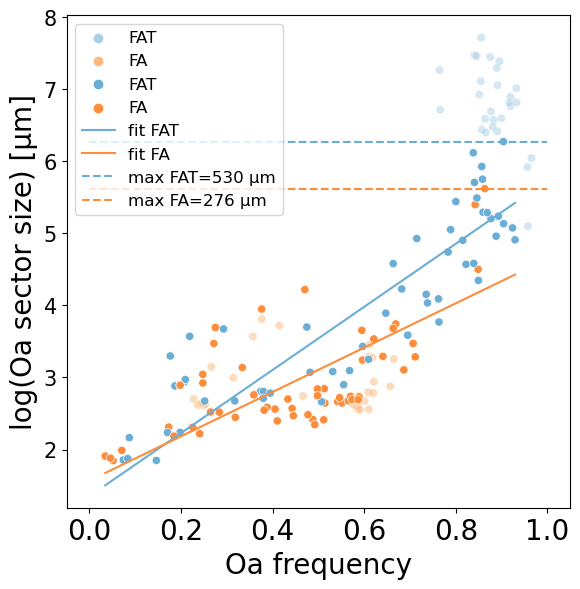

In [25]:
fig, ax = plt.subplots(figsize=(6,6))

# Raw data
sns.scatterplot(
    data=data,
    x="oa_frequency",
    y="log_sector_size_Oa_um",
    hue="media",
    palette={"FAT": blues[0], "FA": oranges[0]},
    ax=ax,
    alpha=0.5
)
sns.scatterplot(
    data=df,
    x="oa_frequency",
    y="log_sector_size_Oa_um",
    hue="media",
    palette={"FAT": blues[1], "FA": oranges[1]},
    ax=ax
)

x_value = np.linspace(df["oa_frequency"].min(), df["oa_frequency"].max(), 100)
plt.plot(x_value, intercept_fat + slope_fat * (x_value-df["oa_frequency"].mean()), color=blues[1],label="fit FAT")
plt.plot(x_value, intercept + slope_fa * (x_value-df["oa_frequency"].mean()), color=oranges[1], label="fit FA")
ax.set_xlabel("Oa frequency")
ax.set_ylabel("log(Oa sector size) [µm]")
ax.hlines(y=np.log(np.max(df[df["media"] == "FAT"]["sector_size_Oa"]*im_resolution)), xmin=0, xmax=1, color=blues[1], linestyle="dashed", label=f"max FAT={np.max(df[df['media'] == 'FAT']['sector_size_Oa'])*im_resolution:.0f} µm")
ax.hlines(y=np.log(np.max(df[df["media"] == "FA"]["sector_size_Oa"]*im_resolution)), xmin=0, xmax=1, color=oranges[1], linestyle="dashed", label=f"max FA={np.max(df[df['media'] == 'FA']['sector_size_Oa'])*im_resolution:.0f} µm")
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_log_oa_ss_vs_oa_freq.pdf", dpi=300)
plt.show()


In [26]:
np.exp(4.7*0.2)

2.5599814183292717

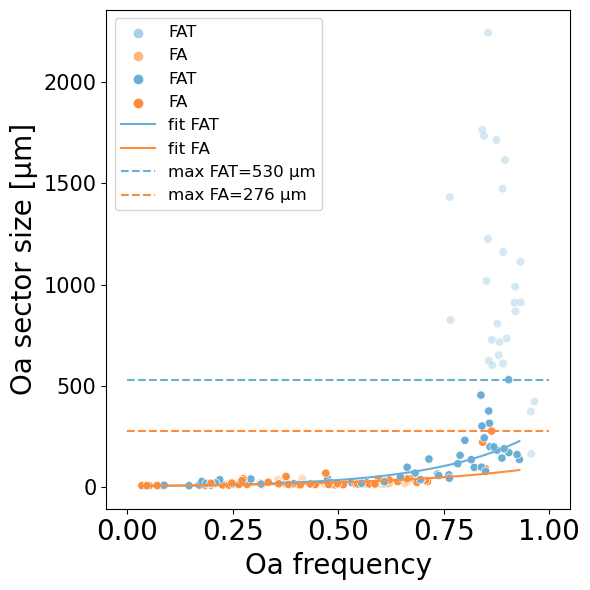

In [27]:
fig, ax = plt.subplots(figsize=(6,6))

# Raw data
sns.scatterplot(
    data=data,
    x="oa_frequency",
    y="sector_size_Oa_um",
    hue="media",
    palette={"FAT": blues[0], "FA": oranges[0]},
    ax=ax,
    alpha=0.5
)
sns.scatterplot(
    data=df,
    x="oa_frequency",
    y="sector_size_Oa_um",
    hue="media",
    palette={"FAT": blues[1], "FA": oranges[1]},
    ax=ax
)

x_value = np.linspace(df["oa_frequency"].min(), df["oa_frequency"].max(), 100)
plt.plot(x_value, np.exp(intercept_fat + slope_fat * (x_value-df["oa_frequency"].mean())), color=blues[1], label="fit FAT")
plt.plot(x_value, np.exp(intercept + slope_fa * (x_value-df["oa_frequency"].mean())), color=oranges[1], label="fit FA")
ax.set_xlabel("Oa frequency")
ax.set_ylabel("Oa sector size [µm]")
ax.hlines(y=np.max(df[df["media"] == "FAT"]["sector_size_Oa_um"]), xmin=0, xmax=1, color=blues[1], linestyle="dashed", label=f"max FAT={np.max(df[df['media'] == 'FAT']['sector_size_Oa_um']):.0f} µm")
ax.hlines(y=np.max(df[df["media"] == "FA"]["sector_size_Oa_um"]), xmin=0, xmax=1, color=oranges[1], linestyle="dashed", label=f"max FA={np.max(df[df['media'] == 'FA']['sector_size_Oa_um']):.0f} µm")
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig(plot_dir / f"{plots_prefix}_oa_ss_vs_oa_freq.pdf", dpi=300)
plt.show()

How to itnterpret the above result? <br> The formula relating S_Oa (Oa sector size) and f_Oa (Oa frequency )is log(S_Oa) = Intercept + freq_centered*f_Oa + C(media)[T.FAT]*FAT + + freq_centered:C(media)[T.FAT]*f_Oa*FAT. <br> From the fact that the slope, i.e. freq_centered, is significant, we conclude that even in FA, sector size increases with frequency. <br> We can compare Intercept with C(media)[T.FAT] to conclude that FAT has larger sector sizes at mean Oa frequency. Specifically, by a factor e^C(media)[T.FAT] = e^0.984 which is about 2.7 times more. <br> We can compare the slope, freq_centered, with freq_centered:C(media)[T.FAT] to conclude that the increase in frequency is much stronger in FAT. <br> Lastly, we can compare partner variance, i.e. Group Var, with the residual variance, i.e. Scale to calculate the ICC = Group Var / (Group Var + Scale) = 0.51 to conclude that 51% of residual variance is due to partner effects.

In [70]:
ols = smf.ols(
    "log_sector_size_Oa_um ~ freq_centered * C(media)",
    data=df
).fit()

print("OLS AIC:", ols.aic)
print("Mixed AIC:", result.aic)
print("Mixed - OLS AIC:", result.aic - ols.aic)

print("OLS BIC:", ols.bic)
print("Mixed BIC:", result.bic)
print("Mixed - OLS BIC:", result.bic - ols.bic)

# log likelihood ratio test
print("OLS log-likelihood:", ols.llf)
print("Mixed log-likelihood:", result.llf)
llr = 2 * (result.llf - ols.llf)
df_diff = result.df_modelwc - ols.df_model
p_value = chi2.sf(llr, df_diff)
print(f"Log-likelihood ratio test: LLR={llr}, df={df_diff}, p-value={p_value}")

OLS AIC: 198.78455808377672
Mixed AIC: 76.25935525486767
Mixed - OLS AIC: -122.52520282890904
OLS BIC: 209.7293518773547
Mixed BIC: 92.67654594523464
Mixed - OLS BIC: -117.05280593212007
OLS log-likelihood: -95.39227904188836
Mixed log-likelihood: -32.129677627433836
Log-likelihood ratio test: LLR=126.52520282890904, df=2.0, p-value=3.3527509547622357e-28


We conclude that the random partner effect is significant.

# Mixed effect model for Oa sector size vs media with partner as random effect

Wilcoxon signed-ranktest: stat=397.0, p-value=4.988849443894224e-06


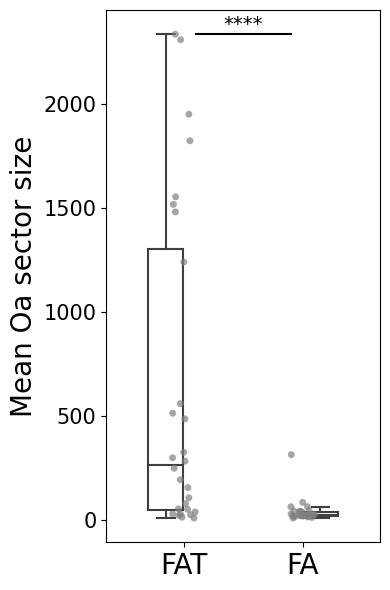

In [61]:
mean_ss = data.groupby(["partner", "media"])["sector_size_Oa"].agg(["mean", "std"]).reset_index()
stat, p_value = wilcoxon(mean_ss[mean_ss["media"] == "FAT"]["mean"], mean_ss[mean_ss["media"] == "FA"]["mean"],alternative="greater")
print(f"Wilcoxon signed-ranktest: stat={stat}, p-value={p_value}")
fig, ax = plt.subplots(figsize=(4,6))
sns.stripplot(data=mean_ss, ax=ax,x="media", y="mean", hue="media",order=media_titles,palette=["gray","gray"], size=5, alpha=0.7)
sns.boxplot(data=mean_ss, ax=ax, x="media", y="mean", hue="media", order=media_titles, hue_order=media_titles, width=0.6, fliersize=0, boxprops={'facecolor':'none'}, showfliers=False)
plt.ylabel("Mean Oa sector size")
plt.xticks([0, 1], media_titles)
plt.legend([],[], frameon=False)
plt.xlabel("")
add_sig_bar(ax, 0.1, 0.9, mean_ss["mean"].max() + 0.001, significance_stars(p_value), h = 0.0005)
plt.tight_layout()

In [62]:
# Partner specific intercept only
m0 = mixedlm(
    "sector_size_Oa ~ media_num",
    data=data,
    groups=data["partner"],
    re_formula="1"
)

result = m0.fit()
print(result.summary())
print(result.cov_re)

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sector_size_Oa
No. Observations: 168     Method:             REML          
No. Groups:       28      Scale:              245568.7049   
Min. group size:  6       Log-Likelihood:     -1287.9161    
Max. group size:  6       Converged:          Yes           
Mean group size:  6.0                                       
------------------------------------------------------------
              Coef.    Std.Err.   z   P>|z|  [0.025   0.975]
------------------------------------------------------------
Intercept       41.325   83.221 0.497 0.619 -121.786 204.436
media_num      593.552   76.465 7.762 0.000  443.683 743.420
Group Var   112066.664   91.824                             

               Group
Group  112066.664213


In [63]:
# Partner specific slope only
m1 = mixedlm(
    "sector_size_Oa ~ media_num",
    data=data,
    groups=data["partner"],
    re_formula="0 + media_num"
)

result = m1.fit()
print(result.summary())
print(result.cov_re)

            Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: sector_size_Oa
No. Observations:  168     Method:             REML          
No. Groups:        28      Scale:              70101.8360    
Min. group size:   6       Log-Likelihood:     -1210.0379    
Max. group size:   6       Converged:          Yes           
Mean group size:   6.0                                       
-------------------------------------------------------------
                Coef.    Std.Err.   z   P>|z|  [0.025  0.975]
-------------------------------------------------------------
Intercept         41.325   28.889 1.431 0.153 -15.295  97.946
media_num        593.552  150.053 3.956 0.000 299.453 887.650
media_num Var 583709.543  681.925                            

               media_num
media_num  583709.542781


In [64]:
slope_variance = result.cov_re.loc["media_num"][0]
slope_sd = np.sqrt(slope_variance)

intercept = result.params["Intercept"]
slope = result.params["media_num"]

# Assess ratio between slope_sd and slope
slope_ratio = slope_sd / slope
print(f"Slope SD: {slope_sd}, Slope: {slope}, Ratio: {slope_ratio}")

Slope SD: 764.0088630254436, Slope: 593.5515055543941, Ratio: 1.2871820825588463


In [67]:
lm = smf.ols("sector_size_Oa ~ media_num", data=data).fit()

lmm = mixedlm(
    "sector_size_Oa ~ media_num",
    data=df,
    groups=df["partner"]
).fit(reml=False)

print(-lm.aic+lmm.aic)
print(-lm.bic+lmm.bic)

-1202.5588476883247
-1197.8619818535533
